In [2]:
import torch
import numpy as np
from torch import Tensor
import matplotlib.pyplot as plt

from src.models import mk_model
from src.plotting import plt_sample
from src.dataset import load_preprocessed_dataset
from src.configs import TrainingConfig, ModelConfig

In [3]:
x_train, y_train, x_test = load_preprocessed_dataset()

target label: 4


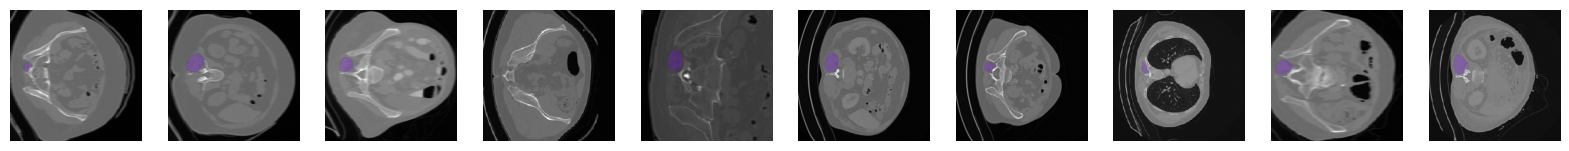

target label: 5


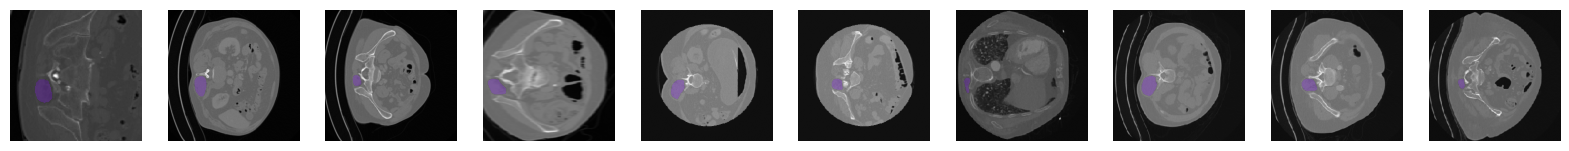

target label: 6


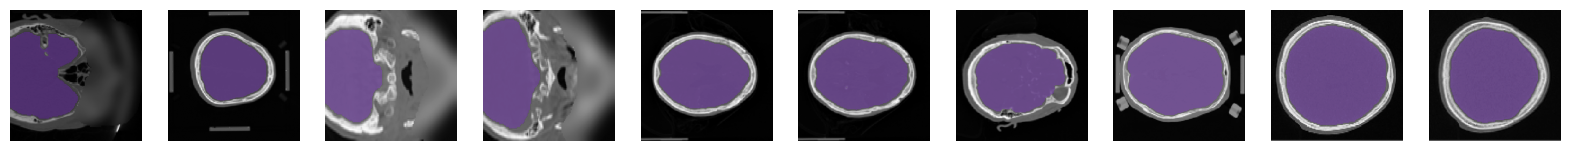

target label: 7


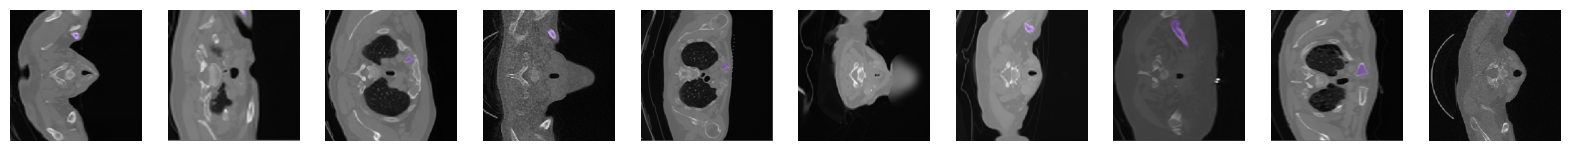

target label: 8


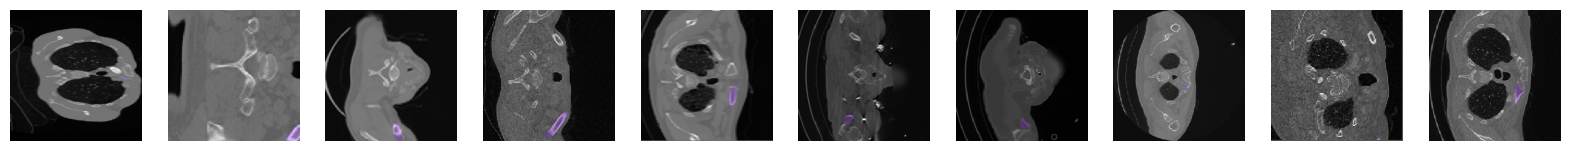

target label: 9


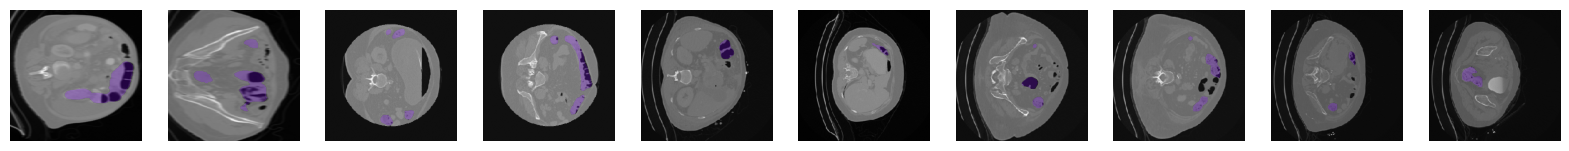

target label: 10


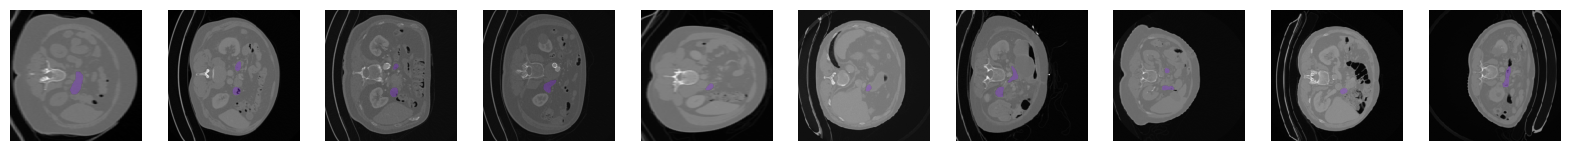

target label: 11


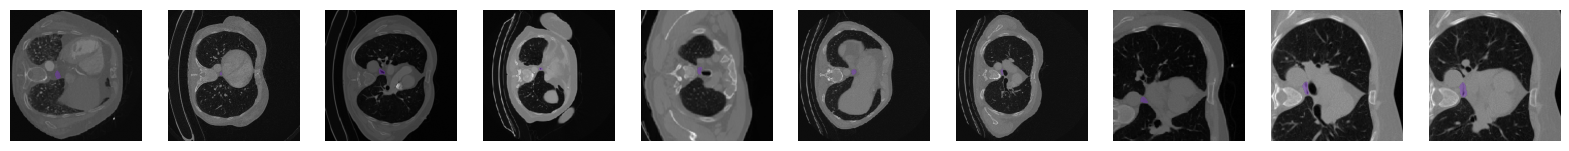

target label: 12


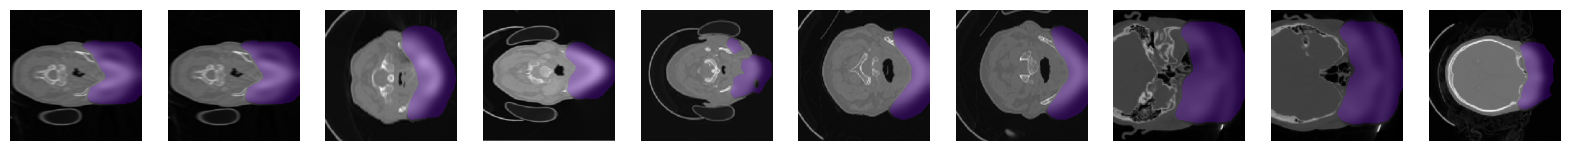

target label: 13


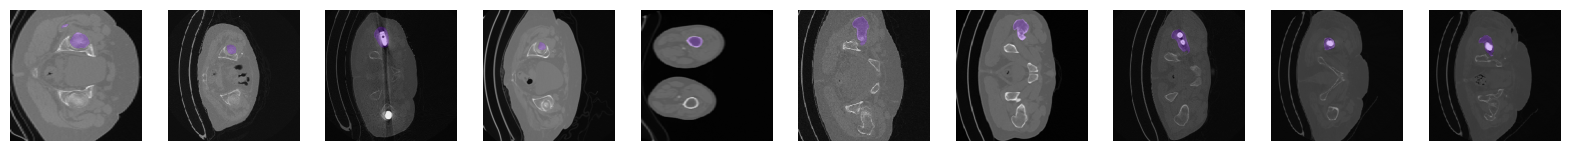

target label: 14


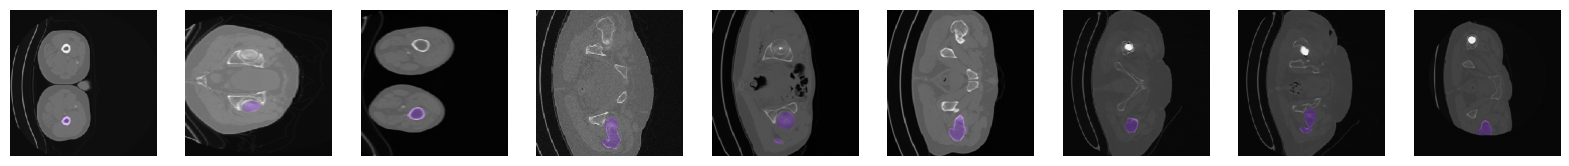

target label: 15


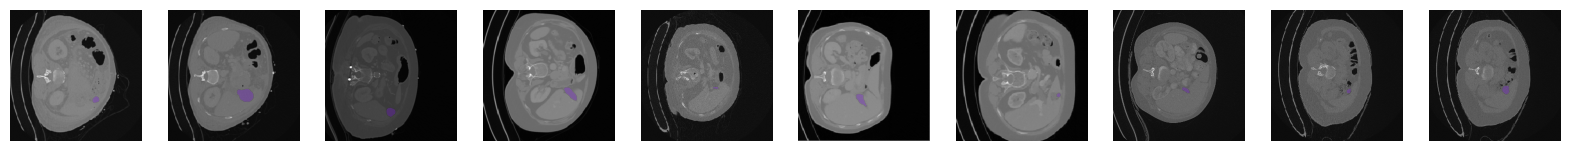

target label: 16


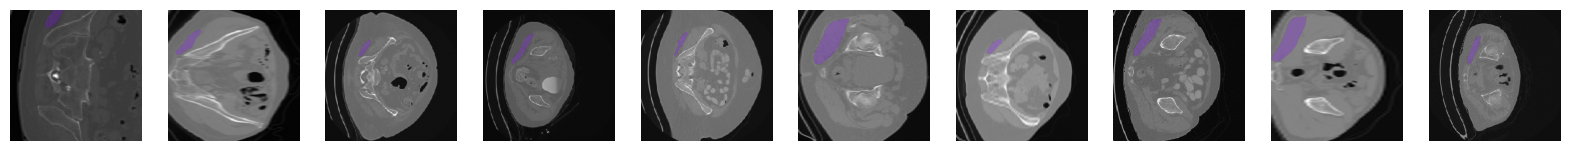

target label: 17


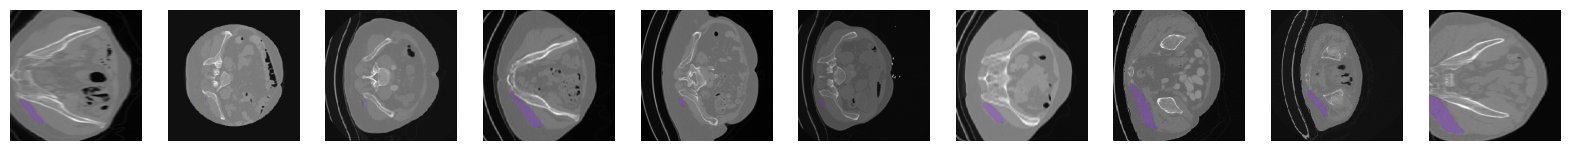

target label: 18


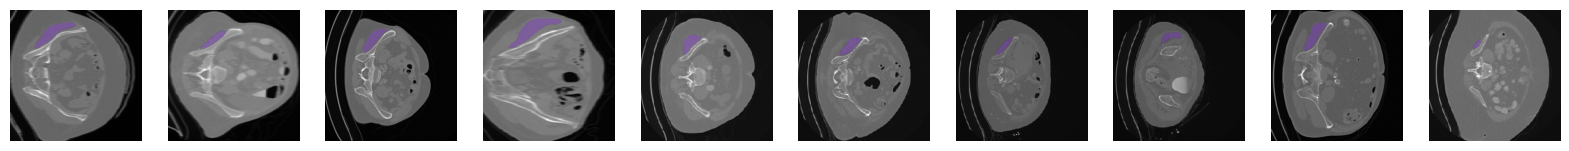

target label: 19


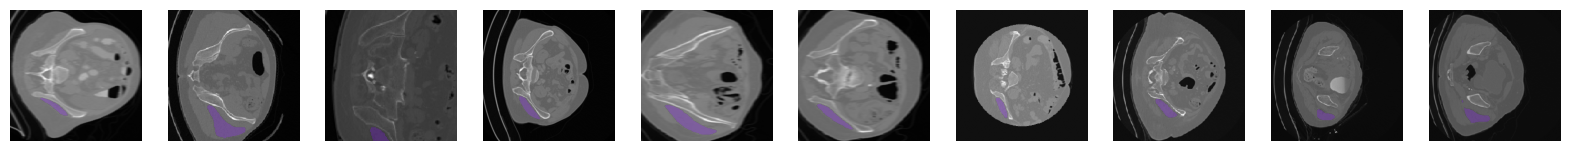

target label: 20


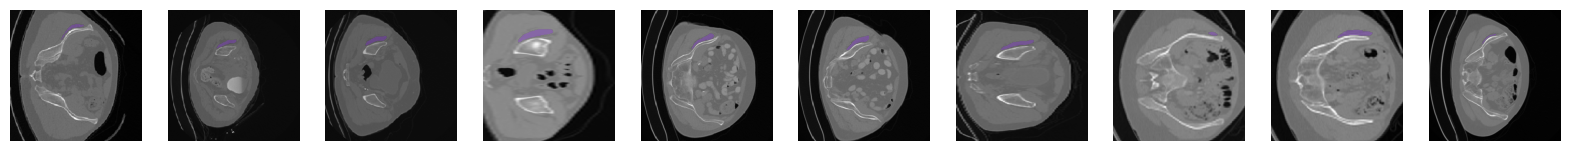

target label: 21


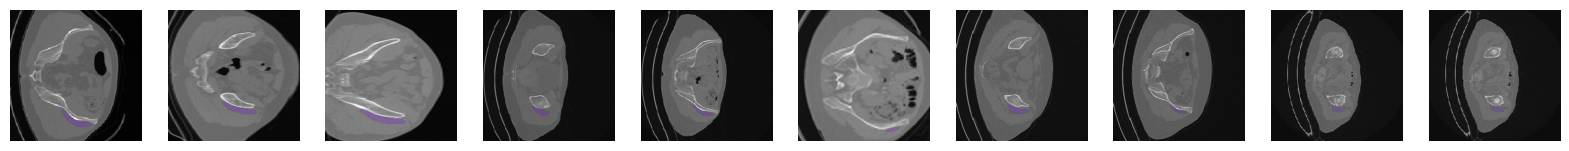

target label: 22


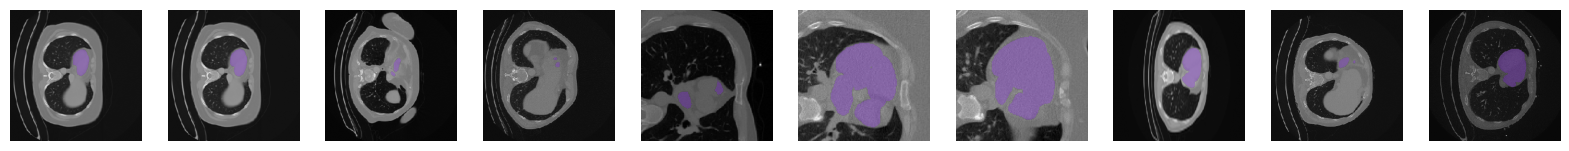

target label: 23


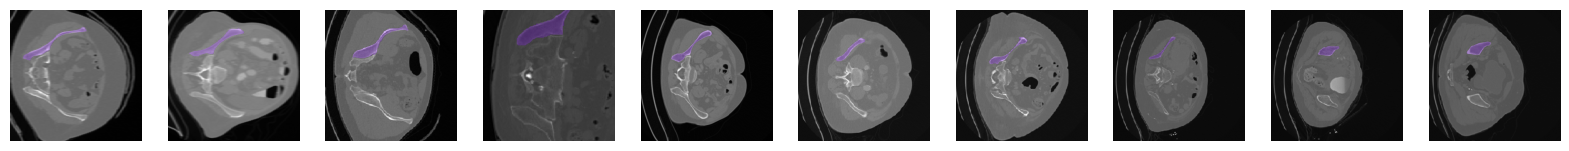

target label: 24


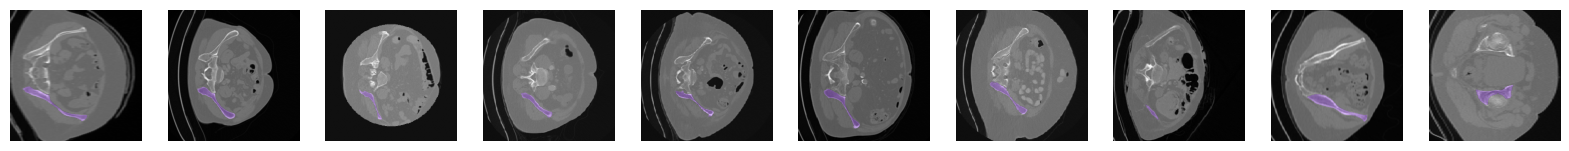

target label: 25


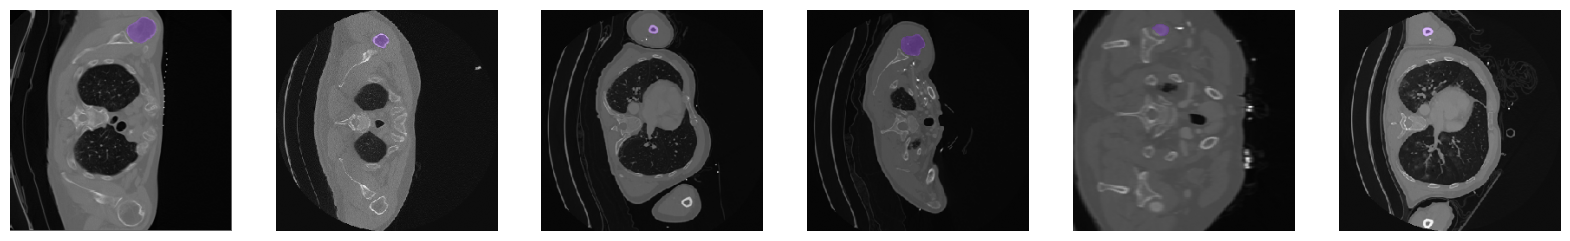

target label: 26


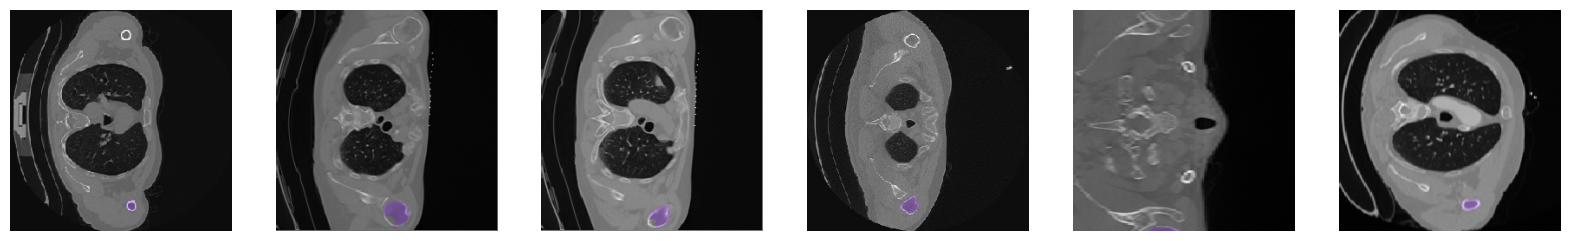

target label: 27


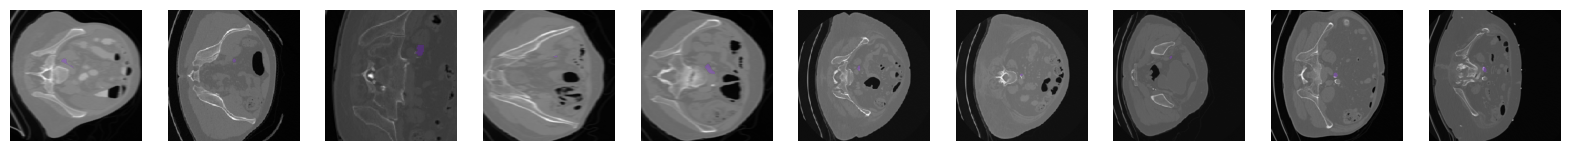

target label: 28


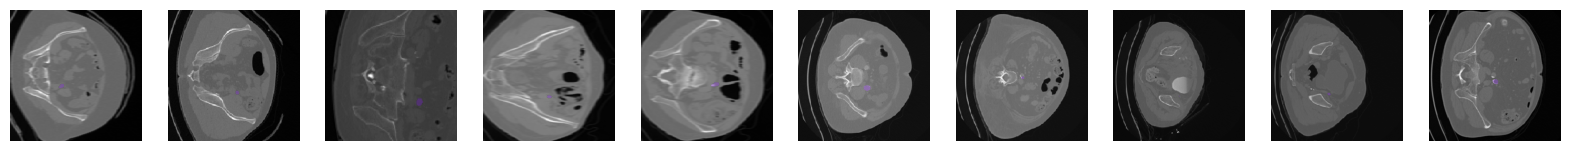

target label: 29


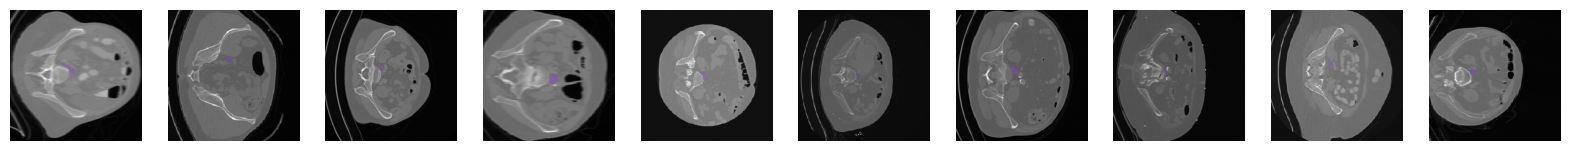

In [20]:
def plt_sample(slice_images: Tensor, seg_masks: Tensor):
    assert slice_images.ndim == 3 and slice_images.ndim == 3
    fig, axes = plt.subplots(1, len(slice_images), figsize=(20, 8))
    for ax_idx, (img, seg) in enumerate(zip(slice_images, seg_masks)):
        axes[ax_idx].imshow(img, cmap="gray")
        seg_masked = np.ma.masked_where(seg == 0, seg)
        axes[ax_idx].imshow(seg_masked, cmap="rainbow", alpha=0.25)
        axes[ax_idx].axis("off")
    plt.show()

N_SAMPLES_TO_PLOT = 10
for target_label in range(4, 30):
    print("target label:", target_label)
    has_label_mask = (y_train.reshape(-1, 256 * 256) == target_label).any(dim=1)
    x_with_label = x_train[has_label_mask]
    y_with_label = y_train[has_label_mask]
    y_with_label[y_with_label != target_label] = 0
    plt_sample(
        x_with_label[:N_SAMPLES_TO_PLOT, 0],
        y_with_label[:N_SAMPLES_TO_PLOT],
    )

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_cfg, model_cfg = TrainingConfig(), ModelConfig()
model = mk_model(train_cfg, model_cfg).to(device)
b_size = 10
x, y_true = x_train[:b_size], y_train[:b_size]
with torch.no_grad():
    y_pred = model(x.to(device))

In [ ]:
display(y_pred.shape)
display(torch.argmax(y_true.reshape(-1, 256 * 256), dim=1))

In [ ]:
from torch.nn.functional import one_hot

def match_pred_and_true(y_pred: Tensor, y_true: Tensor) -> tuple[Tensor, Tensor]:
    one_hot_pred = one_hot(y_pred.type(torch.long)).permute(0, 3, 1, 2).unsqueeze(1)
    one_hot_true = one_hot(y_true.type(torch.long)).permute(0, 3, 1, 2).unsqueeze(2)
    intersection = one_hot_true == one_hot_pred
    union = one_hot_pred[:, None] == one_hot_true[:, :, None]

match_pred_and_true(y_pred, y_true)